### Imports

In [2]:
import re
import random
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Dataset

In [3]:
file_path = "/content/sample_data/rus.txt"

pairs = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            en = parts[0]
            ru = parts[1]
            pairs.append((en, ru))

print("Total sentence pairs:", len(pairs))
print(pairs[:5])

Total sentence pairs: 363386
[('Go.', 'Марш!'), ('Go.', 'Иди.'), ('Go.', 'Идите.'), ('Hi.', 'Здравствуйте.'), ('Hi.', 'Привет!')]


### Text Cleaning

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_pairs = []

for en, ru in pairs:
    en = clean_text(en)
    ru = clean_text(ru)
    if en != "" and ru != "":
        cleaned_pairs.append((en, ru))

print("Cleaned pairs:", len(cleaned_pairs))
print(cleaned_pairs[:5])

Cleaned pairs: 363386
[('go', 'марш'), ('go', 'иди'), ('go', 'идите'), ('hi', 'здравствуйте'), ('hi', 'привет')]


In [5]:
ready_pairs = []

for en, ru in cleaned_pairs[:10000]:
    ru = "<sos> " + ru + " <eos>"
    ready_pairs.append((en, ru))

print(ready_pairs[:5])

[('go', '<sos> марш <eos>'), ('go', '<sos> иди <eos>'), ('go', '<sos> идите <eos>'), ('hi', '<sos> здравствуйте <eos>'), ('hi', '<sos> привет <eos>')]


### Build Vocabulary

In [6]:
def build_vocab(sentences):
    word_counter = Counter()

    for sentence in sentences:
        word_counter.update(sentence.split())

    vocab = {
        "<pad>": 0,
        "<unk>": 1
    }

    for word in word_counter:
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

english_sentences = [x[0] for x in ready_pairs]
russian_sentences = [x[1] for x in ready_pairs]

en_vocab = build_vocab(english_sentences)
ru_vocab = build_vocab(russian_sentences)

print("English vocab size:", len(en_vocab))
print("Russian vocab size:", len(ru_vocab))

English vocab size: 1716
Russian vocab size: 4628


In [7]:
def sentence_to_ids(sentence, vocab):
    words = sentence.split()
    return [vocab.get(word, vocab["<unk>"]) for word in words]

data = []

for en, ru in ready_pairs:
    en_ids = sentence_to_ids(en, en_vocab)
    ru_ids = sentence_to_ids(ru, ru_vocab)
    data.append((en_ids, ru_ids))

print(data[:3])

[([2], [2, 3, 4]), ([2], [2, 5, 4]), ([2], [2, 6, 4])]


### Train and Validation

In [8]:
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))

Train size: 8000
Validation size: 2000


In [9]:
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        en_ids, ru_ids = self.pairs[index]
        return torch.tensor(en_ids), torch.tensor(ru_ids)

In [10]:
def collate_fn(batch):
    en_batch = []
    ru_batch = []

    for en_item, ru_item in batch:
        en_batch.append(en_item)
        ru_batch.append(ru_item)

    en_batch = pad_sequence(en_batch, padding_value=0)
    ru_batch = pad_sequence(ru_batch, padding_value=0)

    return en_batch, ru_batch

In [11]:
train_dataset = TranslationDataset(train_data)
val_dataset = TranslationDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

for en_batch, ru_batch in train_loader:
    print("English batch shape:", en_batch.shape)
    print("Russian batch shape:", ru_batch.shape)
    break

English batch shape: torch.Size([4, 32])
Russian batch shape: torch.Size([7, 32])


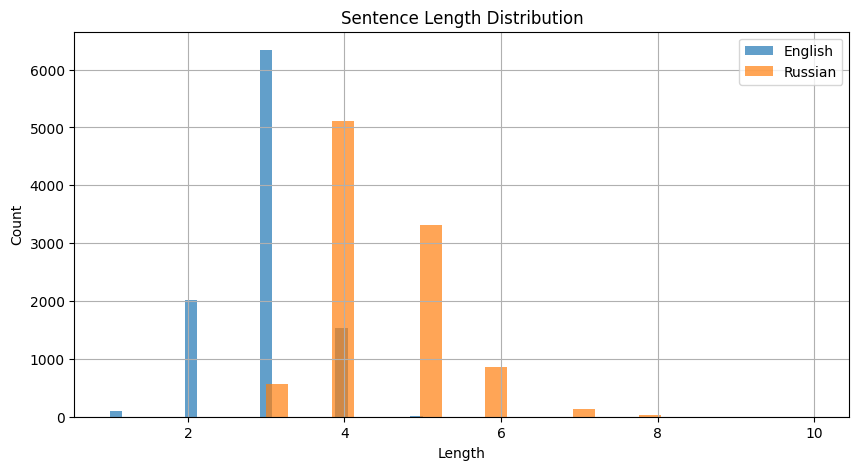

In [12]:
en_lengths = [len(pair[0]) for pair in data]
ru_lengths = [len(pair[1]) for pair in data]

plt.figure(figsize=(10, 5))
plt.hist(en_lengths, bins=25, alpha=0.7, label="English")
plt.hist(ru_lengths, bins=25, alpha=0.7, label="Russian")
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

### Attention Layer

In [14]:
class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()

        self.energy_layer = nn.Linear(hid_dim * 2, hid_dim)
        self.score_layer = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]

        hidden_last = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        joined = torch.cat((hidden_last, encoder_outputs), dim=2)
        energy = torch.tanh(self.energy_layer(joined))
        scores = self.score_layer(energy).squeeze(2)

        attention_weights = torch.softmax(scores, dim=1)
        return attention_weights

### Decoder with Attention

In [15]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim + hid_dim, hid_dim)
        self.fc = nn.Linear(hid_dim * 2 + emb_dim, output_dim)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        input_token = input_token.unsqueeze(0)

        embedded = self.embedding(input_token)

        attn_weights = self.attention(hidden, encoder_outputs).unsqueeze(1)
        encoder_outputs2 = encoder_outputs.permute(1, 0, 2)

        context = torch.bmm(attn_weights, encoder_outputs2).permute(1, 0, 2)

        rnn_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.lstm(rnn_input, (hidden, cell))

        prediction = self.fc(torch.cat((output.squeeze(0), context.squeeze(0), embedded.squeeze(0)), dim=1))

        return prediction, hidden, cell

In [16]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input_token = trg[0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[t] = output

            best_guess = output.argmax(1)
            use_teacher = random.random() < teacher_forcing_ratio
            input_token = trg[t] if use_teacher else best_guess

        return outputs

In [17]:
input_dim = len(en_vocab)
output_dim = len(ru_vocab)
emb_dim = 128
hid_dim = 256

attn = Attention(hid_dim)
enc = Encoder(input_dim, emb_dim, hid_dim)
dec = Decoder(output_dim, emb_dim, hid_dim, attn)

model = Seq2Seq(enc, dec, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=ru_vocab["<pad>"])

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(1716, 128)
    (lstm): LSTM(128, 256)
  )
  (decoder): Decoder(
    (attention): Attention(
      (energy_layer): Linear(in_features=512, out_features=256, bias=True)
      (score_layer): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(4628, 128)
    (lstm): LSTM(384, 256)
    (fc): Linear(in_features=640, out_features=4628, bias=True)
  )
)


In [18]:
def train_model(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for src, trg in loader:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [19]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0)

            output_dim = output.shape[-1]

            output = output[1:].view(-1, output_dim)
            trg = trg[1:].reshape(-1)

            loss = criterion(output, trg)
            total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
epochs = 10

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):
    train_loss = train_model(model, train_loader, optimizer, criterion)
    val_loss = evaluate_model(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "simple_attention_model.pt")

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

Epoch 1: Train Loss = 4.4717, Val Loss = 3.7973
Epoch 2: Train Loss = 2.9526, Val Loss = 3.2900
Epoch 3: Train Loss = 2.0144, Val Loss = 3.0333
Epoch 4: Train Loss = 1.4066, Val Loss = 2.9344
Epoch 5: Train Loss = 1.0932, Val Loss = 2.9835
Epoch 6: Train Loss = 0.9399, Val Loss = 2.9813
Epoch 7: Train Loss = 0.8542, Val Loss = 2.9960
Epoch 8: Train Loss = 0.7964, Val Loss = 3.0475
Epoch 9: Train Loss = 0.7456, Val Loss = 3.0407
Epoch 10: Train Loss = 0.7132, Val Loss = 3.0712


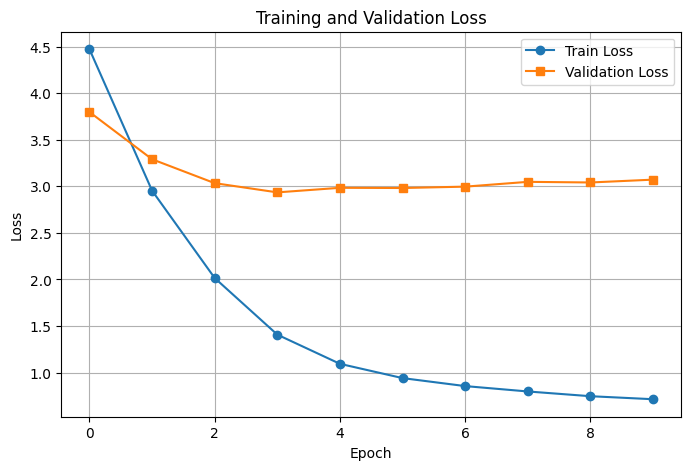

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
ru_index_to_word = {index: word for word, index in ru_vocab.items()}
en_index_to_word = {index: word for word, index in en_vocab.items()}

In [23]:
def translate_sentence(sentence, model, en_vocab, ru_vocab, ru_index_to_word, max_len=20):
    model.eval()

    sentence = clean_text(sentence)
    tokens = sentence.split()
    src_ids = [en_vocab.get(word, en_vocab["<unk>"]) for word in tokens]

    src_tensor = torch.LongTensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    trg_index = ru_vocab["<sos>"]
    result_words = []

    for _ in range(max_len):
        trg_tensor = torch.LongTensor([trg_index]).to(device)

        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell, encoder_outputs)

        pred_token = output.argmax(1).item()
        pred_word = ru_index_to_word[pred_token]

        if pred_word == "<eos>":
            break

        result_words.append(pred_word)
        trg_index = pred_token

    return result_words

In [24]:
model.load_state_dict(torch.load("simple_attention_model.pt", map_location=device))
model.eval()

test_sentences = [
    "hello",
    "how are you",
    "i love you",
    "this is good",
    "where are you",
    "i need help",
    "that is my book"
]

for sentence in test_sentences:
    translated = translate_sentence(sentence, model, en_vocab, ru_vocab, ru_index_to_word)
    print("EN:", sentence)
    print("RU:", " ".join(translated))
    print("-" * 40)

EN: hello
RU: у меня всё
----------------------------------------
EN: how are you
RU: как как
----------------------------------------
EN: i love you
RU: я тебя люблю
----------------------------------------
EN: this is good
RU: это хорошо
----------------------------------------
EN: where are you
RU: я с нами
----------------------------------------
EN: i need help
RU: мне нужна помощь
----------------------------------------
EN: that is my book
RU: это мой
----------------------------------------


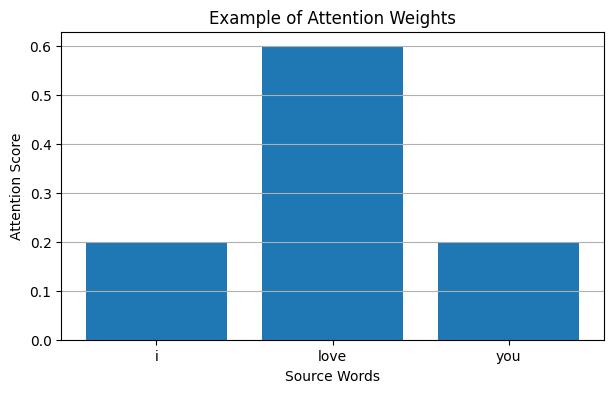

In [25]:
sample_words = ["i", "love", "you"]
sample_scores = [0.2, 0.6, 0.2]

plt.figure(figsize=(7, 4))
plt.bar(sample_words, sample_scores)
plt.title("Example of Attention Weights")
plt.xlabel("Source Words")
plt.ylabel("Attention Score")
plt.grid(True, axis="y")
plt.show()